# Resource Allocation Evaluation

Business Process Optimization

> This notebook evaluates resource allocation methods under controlled simulator settings. The only intended experimental change is the allocation method itself.

In [1]:
import sys
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Evaluation Scope and Basic Metrics

This notebook first evaluates the three basic comparison metrics:

| # | Metric | Definition |
|---|--------|------------|
| 1 | **Average Cycle Time** | Mean case duration from first to last event. |
| 2 | **Average Resource Occupation** | Mean ratio of working time to scheduled available time per resource. |
| 3 | **Resource Fairness (MAD / weighted MAD)** | Deviation of resource occupations from their mean; lower values mean a more balanced workload. |

## Simulation Settings

This section fixes the experimental setup. Only the **resource allocation method** changes between runs.

---

### Process Model

| Setting | Value |
|---|---|
| Model file | `data/process_model.bpmn` |
| Format | BPMN 2.0 (loaded via `sim_core/bpmn_io.py` and converted internally to a Petri net) |
| Activities | Loan-application process with work activities and automatic tasks |

The same process model is used for all methods.

---

### Spawn / Arrival Model

| Setting | Value |
|---|---|
| Spawner class | `AdvancedSpawner` (`spawn_rates/advanced_spawner.py`) |
| Arrival profile | Time-varying rate table derived from the event log |
| Holiday calendar | Netherlands public holidays |
| Max cases | 31 509 |

The same arrival model is used for all methods.

---

### Decision / Routing Rules

| Setting | Value |
|---|---|
| Manager class | `DPManager` (`decision_analysis/DPManager.py`) |
| Mode | `"basic"` |
| Rules file | `decision_analysis/decision_prob_rules.json` |

The same routing rules are used for all methods.

---

### Processing-Time Model

| Setting | Value |
|---|---|
| Sampler class | `ProcessingTimeSampler` (`processing_times/sampling.py`) |
| Model type | Distribution-based per activity |
| Files | `processing_times/Basic_Models/processing_models_proc.json` |
| | `processing_times/Basic_Models/processing_models_full_dur.json` |
| | `processing_times/Basic_Models/wait_reference.json` |
| QR flag | `pt_use_qr=True` |
| Fallback | 60 seconds |

The same processing-time model is used for all methods.

---

### Resource Availability

| Setting | Value |
|---|---|
| Availability file | `resources/availabilities/availabilities_advanced.csv` |
| Schedule type | Shift-based |
| Permissions file | `resources/permissions/role_permissions.csv` |

Resources can only be assigned when they are on shift, not on break, and permitted for the activity.

---

### Simulation Horizon and Replications

| Setting | Value |
|---|---|
| Simulation start | 2016-05-17 09:15:00 |
| Simulation end | 2016-05-31 09:15:00 |
| Horizon | **14 calendar days** |
| Number of replications | **5 per method** |
| Total planned runs | **30** |
| Max-events safety cap | 2 000 000 |

Every method is evaluated on the same fixed simulation window.

---

### Seed Strategy

Seeds are computed as:

```
seed = 1000 × (method_index + 1) + run_index
```

| Method | method_index | Seeds used |
|---|---|---|
| `random` | 0 | 1000, 1001, 1002, 1003, 1004 |
| `round_robin` | 1 | 2000, 2001, 2002, 2003, 2004 |
| `shortest_queue` | 2 | 3000, 3001, 3002, 3003, 3004 |
| `batch_k5` | 3 | 4000, 4001, 4002, 4003, 4004 |
| `advanced_local` | 4 | 5000, 5001, 5002, 5003, 5004 |
| `advanced_global` | 5 | 6000, 6001, 6002, 6003, 6004 |

---

### What Varies vs. What Is Fixed

| Component | Fixed across all runs | Varies |
|---|---|---|
| BPMN / Petri net | ✓ | |
| Arrival profile | ✓ | |
| Decision / routing rules | ✓ | |
| Processing-time model | ✓ | |
| Availability / permissions | ✓ | |
| Simulation horizon | ✓ | |
| Replications per method | ✓ | |
| **Resource allocation method** | | ✓ |
| Random seed | | ✓ |

---

### Allocation Method Definitions

#### 1. Random (`random`)
Chooses uniformly at random from the eligible resources that are on shift, free, and not on break.

#### 2. Round Robin (`round_robin`)
Cycles through eligible resources with a global index and assigns the first available one.

#### 3. Shortest Queue (`shortest_queue`)
Chooses the on-shift resource with the shortest internal queue.

#### 4. Batching (`batch_k5`)
Queues tasks until 5 are waiting, then flushes the batch and assigns them greedily by projected ready time.

#### 5. Advanced Local (`advanced_local`)
Uses local cost predictions to choose the best resource for each task.

#### 6. Advanced Global (`advanced_global`)
Uses a global assignment step to match tasks and resources jointly, including postponement if needed.

## Reproducibility and Notebook Configuration

This section fixes random seeds and display settings so plots and tables stay consistent.

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.options.display.float_format = "{:.4f}".format

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "resources").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root from current working directory.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
STUDY_DIR = REPO_ROOT / "simulation_evaluation" / "resource_allocation"
RESULTS_DIR = STUDY_DIR

print(f"Random seed fixed to: {RANDOM_SEED}")
print(f"Study directory      : {STUDY_DIR}")
print(f"Repository root      : {REPO_ROOT}")

Random seed fixed to: 42
Study directory      : /Users/lucashi/TUM/Praktikum/Group Exercise/bppso-groupwork/simulation_evaluation/resource_allocation
Repository root      : /Users/lucashi/TUM/Praktikum/Group Exercise/bppso-groupwork


## Input Data and Replication Design

Simulation logs are read from `data/<method>/run_NN.csv`.
Each file is one replication with the same simulator settings; only the allocation method differs.

| Method label | Allocation strategy |
|---|---|
| `random` | Uniform random selection from eligible resources |
| `round_robin` | Strict round-robin over eligible resources |
| `shortest_queue` | Resource with the shortest internal queue |
| `batch_k5` | Batching (`k = 5`) with greedy projected-ready-time assignment |
| `advanced_local` | Greedy cost-based assignment |
| `advanced_global` | Global assignment with postponement option |

**Simulation horizon:** fixed at **14 simulated calendar days** for all methods.  
**Completed-case proxy:** cases with more than 2 recorded events.  
**Availability file:** `resources/availabilities/availabilities_advanced.csv`.

In [3]:
DATA_ROOT = STUDY_DIR / "data"

METHODS = {
    "random":          DATA_ROOT / "random",
    "round_robin":     DATA_ROOT / "round_robin",
    "shortest_queue":  DATA_ROOT / "shortest_queue",
    "batch_k5":        DATA_ROOT / "batch_k5",
    "advanced_local":  DATA_ROOT / "advanced_local",
    "advanced_global": DATA_ROOT / "advanced_global",
}

AVAIL_FILE = REPO_ROOT / "resources" / "availabilities" / "availabilities_advanced.csv"
REQUIRED_COLS = {"case:concept:name", "concept:name", "time:timestamp", "lifecycle:transition", "org:resource"}
MIN_EVENTS_PER_CASE = 2  # proxy for completed cases

# Sanity check
for label, path in METHODS.items():
    status = "✓" if path.exists() else "✗ missing"
    print(f"  {label:<16} {status}  ({path})")
print(f"\n  Availability file  {'✓' if AVAIL_FILE.exists() else '✗ missing'}  ({AVAIL_FILE})")

  random           ✓  (/Users/lucashi/TUM/Praktikum/Group Exercise/bppso-groupwork/simulation_evaluation/resource_allocation/data/random)
  round_robin      ✓  (/Users/lucashi/TUM/Praktikum/Group Exercise/bppso-groupwork/simulation_evaluation/resource_allocation/data/round_robin)
  shortest_queue   ✓  (/Users/lucashi/TUM/Praktikum/Group Exercise/bppso-groupwork/simulation_evaluation/resource_allocation/data/shortest_queue)
  batch_k5         ✓  (/Users/lucashi/TUM/Praktikum/Group Exercise/bppso-groupwork/simulation_evaluation/resource_allocation/data/batch_k5)
  advanced_local   ✓  (/Users/lucashi/TUM/Praktikum/Group Exercise/bppso-groupwork/simulation_evaluation/resource_allocation/data/advanced_local)
  advanced_global  ✓  (/Users/lucashi/TUM/Praktikum/Group Exercise/bppso-groupwork/simulation_evaluation/resource_allocation/data/advanced_global)

  Availability file  ✓  (/Users/lucashi/TUM/Praktikum/Group Exercise/bppso-groupwork/resources/availabilities/availabilities_advanced.csv)


## Data Loading

Reads all replication CSVs for each method, checks the required columns, and stores them in `logs`.

In [4]:
def load_method_runs(method_dir: Path) -> list[pd.DataFrame]:
    """Load and validate all run_*.csv files in a method directory."""
    files = sorted(method_dir.glob("run_*.csv"))
    if not files:
        return []
    runs = []
    for f in files:
        df = pd.read_csv(f, parse_dates=["time:timestamp"])
        missing = REQUIRED_COLS - set(df.columns)
        if missing:
            raise ValueError(f"{f.name}: missing columns {missing}")
        runs.append(df)
    return runs


logs: dict[str, list[pd.DataFrame]] = {}
for method, path in METHODS.items():
    if not path.exists():
        logs[method] = []
        continue
    runs = load_method_runs(path)
    logs[method] = runs

## Metric Helper Functions

Shared helper functions for the basic metrics.

In [5]:
import datetime

# Activities with explicit start/complete lifecycle pairs (resource time is measurable)
W_ACTIVITIES = [
    "W_Call after offers",
    "W_Call incomplete files",
    "W_Complete application",
    "W_Handle leads",
    "W_Validate application",
]

DAY_ZERO = datetime.date(2016, 1, 1)  # DayId=0 anchor (matches availability schedule)


def compute_cycle_times(df: pd.DataFrame) -> pd.Series:
    """Per-case cycle time in hours (completed cases only)."""
    ct = df.groupby("case:concept:name")["time:timestamp"].agg(["min", "max"])
    return (ct["max"] - ct["min"]).dt.total_seconds() / 3600


def compute_working_seconds(df: pd.DataFrame) -> pd.Series:
    """Total working seconds per resource from start/complete event pairs."""
    w = df[df["concept:name"].isin(W_ACTIVITIES)].copy()
    starts = (
        w[w["lifecycle:transition"] == "start"]
        [["case:concept:name", "concept:name", "org:resource", "time:timestamp"]]
        .rename(columns={"time:timestamp": "start_time"})
    )
    completes = (
        w[w["lifecycle:transition"] == "complete"]
        [["case:concept:name", "concept:name", "org:resource", "time:timestamp"]]
        .rename(columns={"time:timestamp": "end_time"})
    )
    merged = pd.merge(starts, completes, on=["case:concept:name", "concept:name", "org:resource"])
    merged["working_seconds"] = (merged["end_time"] - merged["start_time"]).dt.total_seconds().clip(lower=0)
    return merged.groupby("org:resource")["working_seconds"].sum()


def compute_available_seconds(avail_df: pd.DataFrame, start_date: datetime.date, end_date: datetime.date) -> pd.Series:
    """Total scheduled seconds per resource over the simulation window."""
    result = {}
    for resource, grp in avail_df.groupby("Resource"):
        total = 0.0
        day = start_date
        while day <= end_date:
            day_id = (day - DAY_ZERO).days % 7
            row = grp[grp["DayId"] == day_id]
            if not row.empty:
                r = row.iloc[0]
                shift_s = datetime.datetime.combine(day, r["StartTime"])
                shift_e = datetime.datetime.combine(day, r["EndTime"])
                total += max(0.0, (shift_e - shift_s).total_seconds() - r["DurationMin"] * 60)
            day += datetime.timedelta(days=1)
        result[resource] = total
    return pd.Series(result, name="available_seconds")


def compute_occupation(working_s: pd.Series, available_s: pd.Series) -> pd.DataFrame:
    """DataFrame with working_seconds, available_seconds, and occupation per resource."""
    df = pd.DataFrame({"working_seconds": working_s, "available_seconds": available_s})
    df["working_seconds"] = df["working_seconds"].fillna(0)
    df = df[df["available_seconds"] > 0].copy()
    df["occupation"] = (df["working_seconds"] / df["available_seconds"]).clip(0, 1)
    return df


def fairness_metrics(occ_series: pd.Series, avail_seconds: pd.Series | None = None) -> tuple:
    """(mean_occ, MAD, weighted MAD). Lower MAD = more balanced workload."""
    mean_occ = occ_series.mean()
    mad = (occ_series - mean_occ).abs().mean()
    if avail_seconds is not None:
        w = avail_seconds / avail_seconds.sum()
        wmad = (w * (occ_series - mean_occ).abs()).sum()
    else:
        wmad = np.nan
    return mean_occ, mad, wmad


# Load and parse availability schedule once
avail_df = pd.read_csv(AVAIL_FILE)
avail_df["StartTime"]   = pd.to_datetime(avail_df["StartTime"],   format="%H:%M:%S").dt.time
avail_df["EndTime"]     = pd.to_datetime(avail_df["EndTime"],     format="%H:%M:%S").dt.time
avail_df["DurationMin"] = avail_df["DurationMin"].fillna(0).astype(int)

print(f"Helpers defined. Availability schedule: {avail_df['Resource'].nunique()} resources, {len(avail_df)} shift rows.")


Helpers defined. Availability schedule: 140 resources, 763 shift rows.


## Per-Method Basic Metric Aggregation

For each method and replication, this section computes:
- mean cycle time
- mean resource occupation
- fairness MAD and weighted MAD

The results are stored in `summary_df`.

In [6]:
records = []

for method, runs in logs.items():
    if not runs:
        continue
    for run_idx, df in enumerate(runs):
        # Filter to completed cases (proxy: > MIN_EVENTS_PER_CASE events)
        counts = df.groupby("case:concept:name").size()
        completed = counts[counts > MIN_EVENTS_PER_CASE].index
        df = df[df["case:concept:name"].isin(completed)].copy()

        if df.empty:
            continue

        # Derive simulation window from the filtered log
        ts = df["time:timestamp"]
        sim_start = ts.min().date()
        sim_end = ts.max().date()

        # Metric 1: cycle time
        ct = compute_cycle_times(df)
        mean_ct = ct.mean()

        # Metric 2 & 3: occupation + fairness
        working_s = compute_working_seconds(df)
        available_s = compute_available_seconds(avail_df, sim_start, sim_end)
        occ_df = compute_occupation(working_s, available_s)
        mean_occ, mad, wmad = fairness_metrics(occ_df["occupation"], occ_df["available_seconds"])

        records.append({
            "method": method,
            "run": run_idx,
            "n_cases": df["case:concept:name"].nunique(),
            "mean_ct_h": mean_ct,
            "mean_occ": mean_occ,
            "fairness_mad": mad,
            "fairness_wmad": wmad,
        })

if records:
    summary_df = pd.DataFrame(records)
    print(summary_df.to_string(index=False))
else:
    summary_df = pd.DataFrame(columns=["method", "run", "n_cases", "mean_ct_h", "mean_occ", "fairness_mad", "fairness_wmad"])
    print("No data loaded — run the study script and place CSVs in data/<method>/")

         method  run  n_cases  mean_ct_h  mean_occ  fairness_mad  fairness_wmad
         random    0     1582     8.0596    0.1955        0.0895         0.0940
         random    1     1538     8.4774    0.2167        0.1124         0.1190
         random    2     1533     8.5975    0.2101        0.1050         0.1145
         random    3     1443     7.9409    0.1847        0.1017         0.1080
         random    4     1518     8.1265    0.1944        0.0912         0.0958
    round_robin    0     1534     8.8686    0.2314        0.1602         0.1633
    round_robin    1     1507     8.9051    0.2243        0.1598         0.1602
    round_robin    2     1528     8.8289    0.2462        0.1715         0.1774
    round_robin    3     1495     8.5996    0.2208        0.1578         0.1540
    round_robin    4     1498     8.5000    0.2176        0.1621         0.1659
 shortest_queue    0     1528    10.2527    0.2229        0.2551         0.2539
 shortest_queue    1     1587    10.4338

## Basic Metric Summary Table

Aggregate performance across replications (`mean ± std`) for the three basic metrics.

In [7]:
if summary_df.empty:
    print("summary_df is empty. Run the aggregation cell first.")
else:
    summary_stats = (
        summary_df
        .groupby("method", as_index=True)
        .agg(
            n_cases_mean=("n_cases", "mean"),
            n_cases_std=("n_cases", "std"),
            mean_ct_h_mean=("mean_ct_h", "mean"),
            mean_ct_h_std=("mean_ct_h", "std"),
            mean_occ_mean=("mean_occ", "mean"),
            mean_occ_std=("mean_occ", "std"),
            fairness_mad_mean=("fairness_mad", "mean"),
            fairness_mad_std=("fairness_mad", "std"),
            fairness_wmad_mean=("fairness_wmad", "mean"),
            fairness_wmad_std=("fairness_wmad", "std"),
        )
        .sort_index()
    )
    display(summary_stats.round(4))

,n_cases_mean,n_cases_std,mean_ct_h_mean,mean_ct_h_std,mean_occ_mean,mean_occ_std,fairness_mad_mean,fairness_mad_std,fairness_wmad_mean,fairness_wmad_std
method,,,,,,,,,,
advanced_global,849.8000,420.8607,12.2842,1.7510,0.2381,0.0177,0.2593,0.0161,0.2597,0.0144
advanced_local,1514.6000,28.4482,14.1222,1.4660,0.2386,0.0031,0.2571,0.0058,0.2563,0.0050
batch_k5,1429.6000,38.6238,6.0796,0.1184,0.1653,0.0115,0.2198,0.0143,0.2265,0.0157
random,1522.8000,50.5737,8.2404,0.2824,0.2003,0.0129,0.1000,0.0096,0.1063,0.0111
round_robin,1512.4000,17.6720,8.7404,0.1796,0.2281,0.0114,0.1623,0.0054,0.1642,0.0086
shortest_queue,1531.8000,36.6906,10.4062,0.3715,0.2276,0.0146,0.2618,0.0136,0.2626,0.0155


## Cycle Time Comparison

Mean cycle time per method with standard-deviation error bars across replications.

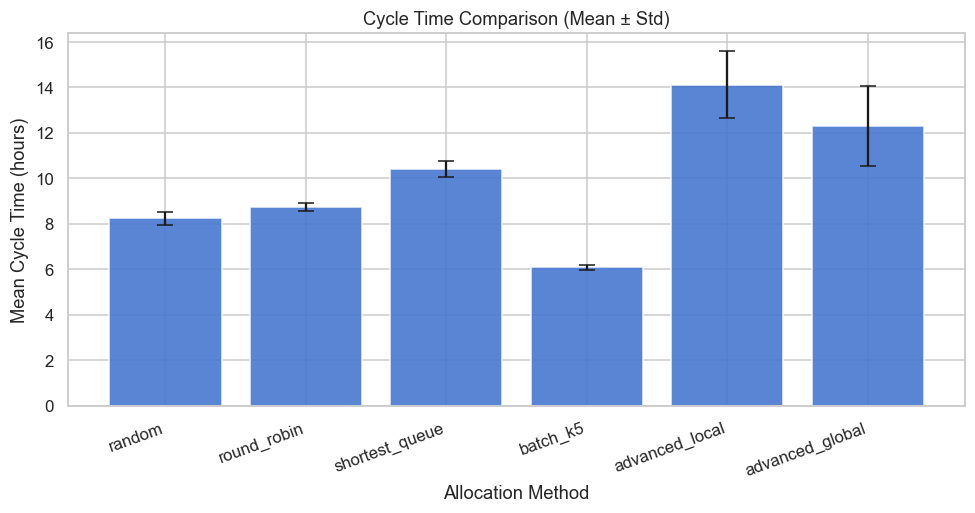

In [8]:
if summary_df.empty:
    print("summary_df is empty. Run the aggregation cell first.")
else:
    ct_plot = (
        summary_df.groupby("method", as_index=False)
        .agg(mean=("mean_ct_h", "mean"), std=("mean_ct_h", "std"))
    )
    order = ["random", "round_robin", "shortest_queue", "batch_k5", "advanced_local", "advanced_global"]
    ct_plot["method"] = pd.Categorical(ct_plot["method"], categories=order, ordered=True)
    ct_plot = ct_plot.sort_values("method")

    plt.figure(figsize=(9, 4.8))
    plt.bar(ct_plot["method"], ct_plot["mean"], yerr=ct_plot["std"], capsize=5, alpha=0.9)
    plt.ylabel("Mean Cycle Time (hours)")
    plt.xlabel("Allocation Method")
    plt.title("Cycle Time Comparison (Mean ± Std)")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

`batch_k5` has the lowest mean cycle time at **6.08 h**. It is followed by `random` (**8.24 h**) and `round_robin` (**8.74 h**). `shortest_queue` is at **10.41 h**, `advanced_global` at **12.28 h**, and `advanced_local` is highest at **14.12 h**. This means `batch_k5` is clearly the fastest in this setup, while both advanced methods show substantially longer end-to-end cycle times.

The advanced global method shows substantially higher variability across replications than the other evaluated approaches, so its average values should be interpreted with additional caution.

## Resource Occupation Comparison

Mean resource occupation per method with standard-deviation error bars across replications.

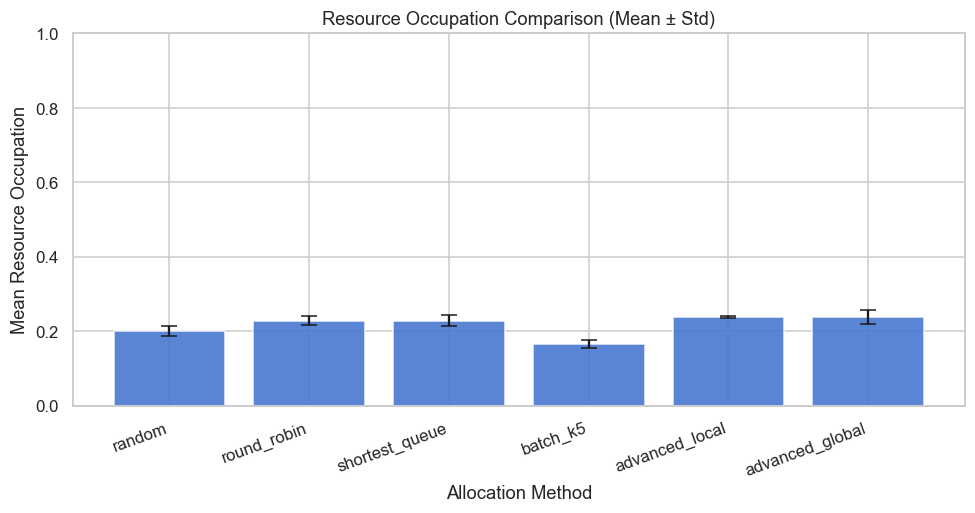

In [9]:
if summary_df.empty:
    print("summary_df is empty. Run the aggregation cell first.")
else:
    occ_plot = (
        summary_df.groupby("method", as_index=False)
        .agg(mean=("mean_occ", "mean"), std=("mean_occ", "std"))
    )
    order = ["random", "round_robin", "shortest_queue", "batch_k5", "advanced_local", "advanced_global"]
    occ_plot["method"] = pd.Categorical(occ_plot["method"], categories=order, ordered=True)
    occ_plot = occ_plot.sort_values("method")

    plt.figure(figsize=(9, 4.8))
    plt.bar(occ_plot["method"], occ_plot["mean"], yerr=occ_plot["std"], capsize=5, alpha=0.9)
    plt.ylabel("Mean Resource Occupation")
    plt.xlabel("Allocation Method")
    plt.title("Resource Occupation Comparison (Mean ± Std)")
    plt.ylim(0, 1)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

The highest mean occupation is observed for `advanced_local` (**0.2386**) and `advanced_global` (**0.2381**), followed by `round_robin` (**0.2281**) and `shortest_queue` (**0.2276**). `random` is at **0.2003**, while `batch_k5` is lowest at **0.1653**. Together with cycle time, this suggests that higher utilization does not automatically translate into better end-to-end performance.

## Fairness (MAD) Comparison

Mean workload fairness MAD per method with standard-deviation error bars across replications (lower is better).

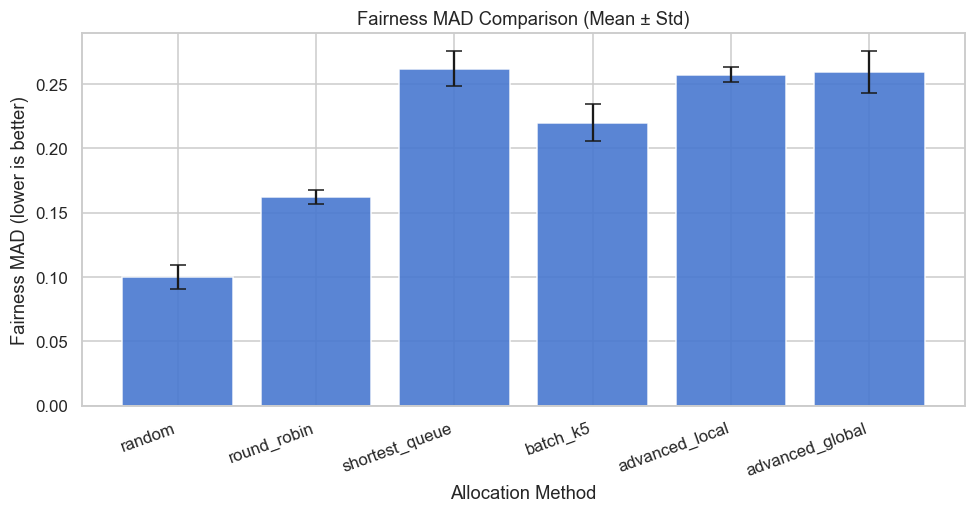

In [10]:
if summary_df.empty:
    print("summary_df is empty. Run the aggregation cell first.")
else:
    fair_plot = (
        summary_df.groupby("method", as_index=False)
        .agg(mean=("fairness_mad", "mean"), std=("fairness_mad", "std"))
    )
    order = ["random", "round_robin", "shortest_queue", "batch_k5", "advanced_local", "advanced_global"]
    fair_plot["method"] = pd.Categorical(fair_plot["method"], categories=order, ordered=True)
    fair_plot = fair_plot.sort_values("method")

    plt.figure(figsize=(9, 4.8))
    plt.bar(fair_plot["method"], fair_plot["mean"], yerr=fair_plot["std"], capsize=5, alpha=0.9)
    plt.ylabel("Fairness MAD (lower is better)")
    plt.xlabel("Allocation Method")
    plt.title("Fairness MAD Comparison (Mean ± Std)")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

`random` performs best on fairness MAD (**0.1000**), followed by `round_robin` (**0.1623**). `batch_k5` is at **0.2198**, while `advanced_local` (**0.2571**), `advanced_global` (**0.2593**), and `shortest_queue` (**0.2618**) show the largest imbalance. In the final runs, `random` and `round_robin` therefore provide the most balanced workload distribution.

## Advanced Metrics

These two metrics add a more process-level view:

- **OLI** shows how much repeated offer-loop work happens per completed case.
- **CHR** shows how often a case changes resource from one step to the next.

### Offer Loop Intensity (OLI)

Offer-related events per completed case.

$$
\mathrm{OLI} = \frac{\#O\_Create\ Offer + \#W\_Call\ after\ offers + \#O\_Cancelled}{\#\text{completed cases}}
$$

In [11]:
OLI_ACTS = {"O_Create Offer", "W_Call after offers", "O_Cancelled"}

oli_rows = []
for method, runs in logs.items():
    for run_idx, df in enumerate(runs):
        # same completed-case proxy as basic section
        counts = df.groupby("case:concept:name").size()
        completed = counts[counts > MIN_EVENTS_PER_CASE].index
        n = len(completed)
        if n == 0:
            continue
        df_c = df[df["case:concept:name"].isin(completed)]
        count = df_c[
            df_c["concept:name"].isin(OLI_ACTS) & (df_c["lifecycle:transition"] == "complete")
        ].shape[0]
        oli_rows.append({"method": method, "run": run_idx, "oli": count / n})

oli_df = pd.DataFrame(oli_rows)

         method    mean    std
         random 17.3623 0.3200
    round_robin 17.5364 0.1425
 shortest_queue 17.1023 0.2703
       batch_k5  4.8556 0.1168
 advanced_local 17.0634 0.2620
advanced_global 16.3483 1.1594


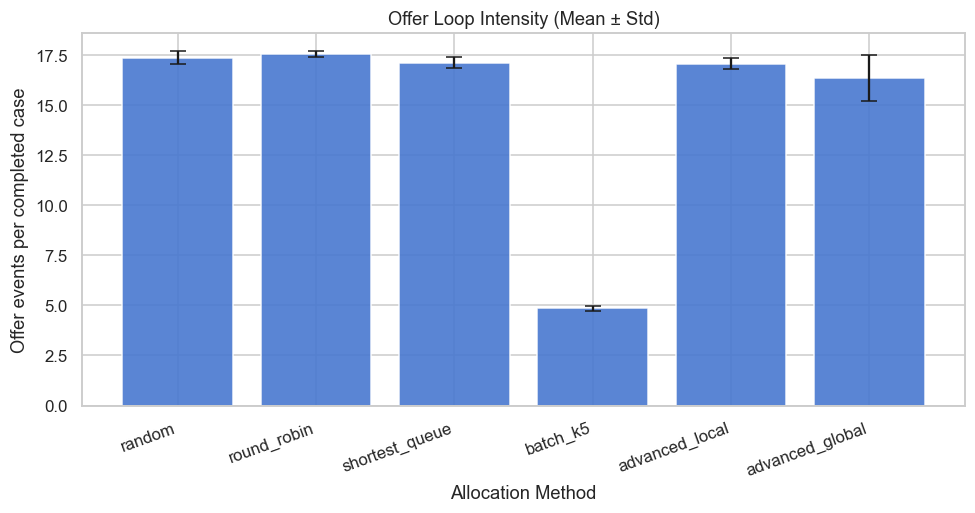

In [12]:
oli_plot = (
    oli_df.groupby("method", as_index=False)
    .agg(mean=("oli", "mean"), std=("oli", "std"))
)
order = ["random", "round_robin", "shortest_queue", "batch_k5", "advanced_local", "advanced_global"]
oli_plot["method"] = pd.Categorical(oli_plot["method"], categories=order, ordered=True)
oli_plot = oli_plot.sort_values("method")

print(oli_plot.round(4).to_string(index=False))

plt.figure(figsize=(9, 4.8))
plt.bar(oli_plot["method"], oli_plot["mean"], yerr=oli_plot["std"], capsize=5, alpha=0.9)
plt.ylabel("Offer events per completed case")
plt.xlabel("Allocation Method")
plt.title("Offer Loop Intensity (Mean ± Std)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

`batch_k5` has by far the lowest OLI at **4.8556**. All other methods are much higher: `advanced_global` **16.3483**, `advanced_local` **17.0634**, `shortest_queue` **17.1023**, `random` **17.3623**, and `round_robin` **17.5364**. Lower OLI means fewer repeated offer-loop events and therefore less repeated effort per completed case.

### Case Handoff Rate (CHR)

Share of consecutive case steps where the resource changes.

$$
\mathrm{CHR} = \frac{\text{resource changes between consecutive steps}}{\text{all consecutive step pairs}}
$$

In [13]:
def case_handoff_rate(df):
    # same completed-case proxy as basic section
    counts = df.groupby("case:concept:name").size()
    completed = counts[counts > MIN_EVENTS_PER_CASE].index
    if len(completed) == 0:
        return float("nan")
    df_c = df[df["case:concept:name"].isin(completed)].sort_values(["case:concept:name", "time:timestamp"])
    rates = []
    for _, grp in df_c.groupby("case:concept:name"):
        seq = (
            grp[grp["lifecycle:transition"] == "complete"]["org:resource"]
            .dropna()
            .tolist()
        )
        if len(seq) < 2:
            continue
        pairs = list(zip(seq[:-1], seq[1:]))
        rates.append(sum(a != b for a, b in pairs) / len(pairs))
    return float(pd.Series(rates).mean()) if rates else float("nan")

chr_rows = []
for method, runs in logs.items():
    for run_idx, df in enumerate(runs):
        chr_rows.append({"method": method, "run": run_idx, "chr": case_handoff_rate(df)})

chr_df = pd.DataFrame(chr_rows)

         method   mean    std
         random 0.8495 0.0046
    round_robin 0.8521 0.0054
 shortest_queue 0.4254 0.0022
       batch_k5 0.7108 0.0050
 advanced_local 0.8427 0.0078
advanced_global 0.8378 0.0143


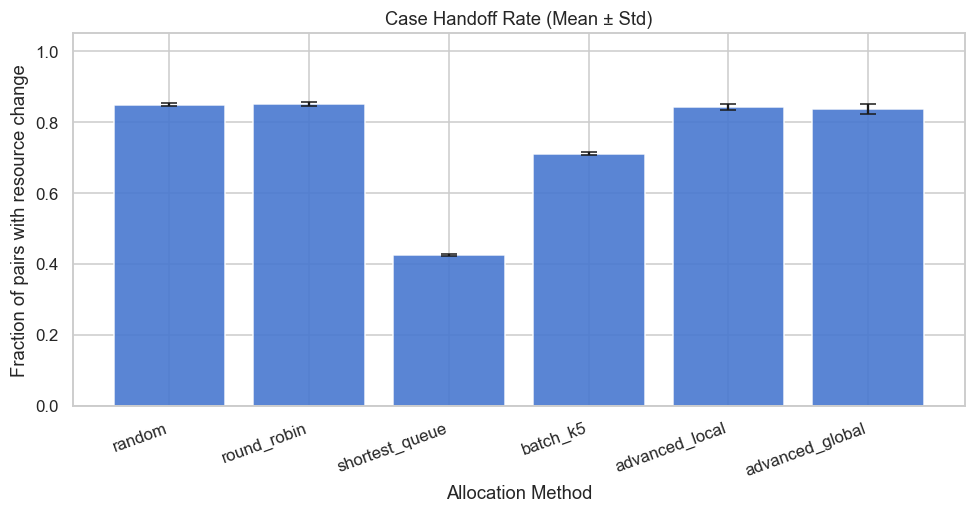

In [14]:
chr_plot = (
    chr_df.groupby("method", as_index=False)
    .agg(mean=("chr", "mean"), std=("chr", "std"))
)
order = ["random", "round_robin", "shortest_queue", "batch_k5", "advanced_local", "advanced_global"]
chr_plot["method"] = pd.Categorical(chr_plot["method"], categories=order, ordered=True)
chr_plot = chr_plot.sort_values("method")

print(chr_plot.round(4).to_string(index=False))

plt.figure(figsize=(9, 4.8))
plt.bar(chr_plot["method"], chr_plot["mean"], yerr=chr_plot["std"], capsize=5, alpha=0.9)
plt.ylabel("Fraction of pairs with resource change")
plt.xlabel("Allocation Method")
plt.title("Case Handoff Rate (Mean ± Std)")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

`shortest_queue` has the lowest CHR at **0.4254**, meaning it keeps cases with the same resource most often (more continuity). `batch_k5` is in the middle (**0.7108**). The highest handoff rates are `round_robin` (**0.8521**) and `random` (**0.8495**); `advanced_local` (**0.8427**) and `advanced_global` (**0.8378**) are slightly lower. In this metric, lower CHR reflects more continuity, while higher CHR reflects more fragmentation.